In [5]:

import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
import importlib
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from urllib.parse import urlparse
from datetime import datetime, timedelta
import geoquant.configs.config as config
import geoquant.data_io as f1
import geoquant.series_utils as f2
import geoquant.risk_matrix as risk_matrix
import geoquant.books as books
import logging
from geoquant.books import IBKR_live

importlib.reload(books)
importlib.reload(f2)
importlib.reload(config)

logging.getLogger().setLevel(logging.INFO)
print('ok')


ok


In [6]:

# book = 'tight_test' 
# book = 'IBKR_live' 
book = 'all_holdings' 
# book = 'risk_test' 
target_weights = False


PORTFOLIO=getattr(books, book)  # verify it exists

print('PORTFOLIO:', book)

data_params = config.data_params
# print('data_params:', data_params)
start = data_params.get('start')
end = data_params.get('end')
start_date = pd.to_datetime(start).date()
end_date = pd.to_datetime(end).date()
print(f'start: {start_date}, end: {end_date}')
DEBUG = False
# print('------\nBOOK:', PORTFOLIO, '\n-------')
max_age = data_params.get('max_age', 0)
print('max_age (hrs):', max_age, '\n-------')

# DIAGNOSTIC: Check earliest date for each asset before alignment
print('\n--- DATA COVERAGE DIAGNOSTIC ---\n(always truncated to item with shortest history)')
for h in PORTFOLIO:
    if h.get('type', '').lower() != 'cash':
        ticker = h.get('ticker')
        name = h['name']
        try:
            px_df = f1.fetch_csv(ticker, data_params=data_params)
            earliest = px_df.index.min().date()
            latest = px_df.index.max().date()
            print(f'{name} ({ticker}): {earliest} to {latest}')
        except Exception as e:
            print(f'{name} ({ticker}): ERROR - {e}')
print('---\n')

importlib.reload(risk_matrix)
rets_df, prices_df, w, rebalance_df = risk_matrix.build_returns_weights(PORTFOLIO, data_params=config.data_params, no_fx=False, usd_shift=False, use_target_weights=target_weights)

print(f'rets_df range: {rets_df.index.min().date()} to {rets_df.index.max().date()}')
print(f'rets_df shape: {rets_df.shape}')

if rebalance_df is not None:
    print('\n--- REBALANCE ---')
    print(rebalance_df[['target_weight','current_chf','desired_chf','delta_chf','current_position','desired_position','delta_shares']].round({'target_weight':3,'current_chf':0,'desired_chf':0,'delta_chf':0,'current_position':0,'desired_position':1,'delta_shares':1}))
    print('---\n')

risk = risk_matrix.portfolio_risk(rets_df, w)

# print( rets_df.tail(3) )
print("------------\nPortfolio σ (an_adjnualized, CHF): {:.2%}".format(risk["port_vol"]))
print(" CORE EQUITY BAND = 15 - 30%, DIVERSIFIERS = 5 - 12%, TACTICALS <= 10%,")
print('equity core max 30%, diversifiers max 12%, tacticals max 10%, total max 15%')
print('RISK ["SUMMARY"]:')
print(risk["summary"].round({"Weight":3,"Vol_1Y_CHF":3,"MRC":3,"PRC_%":1, }))
print(f'CORRELATION:')
print(f'{risk["corr"].round(2)}')
print(f'COVARIANCE:')
print(f'{risk["cov_annual"]}')

corr_matrix = risk["corr"]


PORTFOLIO: all_holdings
start: 2025-05-01, end: 2026-05-14
max_age (hrs): 24 
-------

--- DATA COVERAGE DIAGNOSTIC ---
(always truncated to item with shortest history)
XMWX (XMWX.LSE): 2024-09-03 to 2026-05-12
EMIM (EMIM.LSE): 2024-09-02 to 2026-05-12
GWX (GWX.US): 2024-09-03 to 2026-05-12
VUAG (VUAG.LSE): 2024-09-02 to 2026-05-12
SGLN (SGLN.LSE): 2024-09-02 to 2026-05-12
BATG (BATG.LSE): 2024-09-02 to 2026-05-12
ULVR (ULVR.LSE): 2025-05-01 to 2026-05-13
NWG (NWG.LSE): 2025-05-01 to 2026-05-13
---

rets_df range: 2025-05-02 to 2026-05-12
rets_df shape: (253, 8)
------------
Portfolio σ (an_adjnualized, CHF): 12.04%
 CORE EQUITY BAND = 15 - 30%, DIVERSIFIERS = 5 - 12%, TACTICALS <= 10%,
equity core max 30%, diversifiers max 12%, tacticals max 10%, total max 15%
RISK ["SUMMARY"]:
      Weight  Vol_1Y_CHF    MRC  PRC_%
ULVR   0.472       0.190  0.156   61.0
EMIM   0.135       0.171  0.099   11.1
XMWX   0.157       0.123  0.084   11.0
BATG   0.050       0.270  0.133    5.6
GWX    0.082   

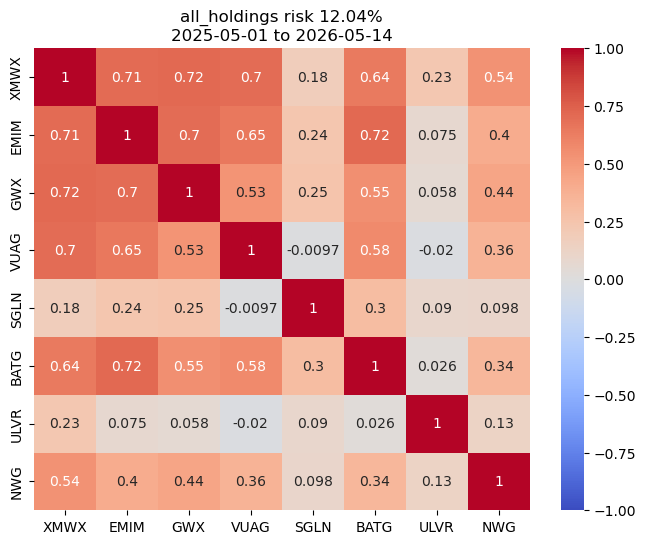

POSITION RETURNS:
XMWX     2.75%
EMIM     4.87%
GWX      2.18%
VUAG     0.86%
SGLN     1.39%
BATG     4.27%
ULVR    -8.43%
NWG      0.26%
book rets 7.79%


In [7]:

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title(f"{book} risk {risk['port_vol']:.2%}\n{start_date} to {end_date}")
plt.show()

total, position_returns = risk_matrix.book_total_returns(rets_df, w)
print('POSITION RETURNS:')
print(position_returns.to_string())
print("book rets", f"{total:.2%}")

## Equity correlation drift check
We’ll:
- compute a 60-day rolling average pairwise correlation across the equity ETFs in your `rets_df`.
- show the 1-year view you’re using now (limited by `XMWX`).
- also compute a 3-year view excluding `XMWX` (if data exist), to see whether the increase is structural or just recent.

In [8]:
# 1) Current 1-year view (already in rets_df)
# Pick equity ETFs present in rets_df
all_cols = list(rets_df.columns)
EQUITY_LIKE = [c for c in ["EMIM","GWX","BATG","XMWX","SGLN", 'YCA'] if c in all_cols]

if len(EQUITY_LIKE) >= 2:
    rets_eq_1y = rets_df[EQUITY_LIKE]
    # 60D rolling average of pairwise correlation (off-diagonal mean)
    def offdiag_mean(corr_m):
        if corr_m.shape[0] < 2:
            return np.nan
        n = corr_m.shape[0]
        return (corr_m.values.sum() - n) / (n*(n-1))

    roll_avg_corr_1y = (
        rets_eq_1y.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
    )

    print("1Y rolling(60) avg pairwise equity corr (tail):")
    print(roll_avg_corr_1y.dropna().tail(10))
else:
    print("Not enough equity-like tickers to compute 1Y pairwise correlation.")

# 2) Longer 3Y view excluding XMWX (if data available): re-fetch or extend window is out of scope here,
# but we can approximate by checking if older data exist in prices_df; if not, we demonstrate exclusion-only.
try:
    # If you want to explicitly exclude XMWX to avoid its shorter history limiting the window
    EQUITY_NO_XMWX = [c for c in EQUITY_LIKE if c != "XMWX"]
    if len(EQUITY_NO_XMWX) >= 2:
        # Use available rets_df (1Y). For a true 3Y view, rerun 
        rets_eq_ex = rets_df[EQUITY_NO_XMWX]
        roll_avg_corr_ex = (
            rets_eq_ex.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
        )
        print("Ex-XMWX rolling(60) avg pairwise equity corr (tail):")
        print(roll_avg_corr_ex.dropna().tail(756))
    else:
        print("Not enough non-XMWX equity-like tickers to compute ex-XMWX correlation.")
except Exception as e:
    print("Correlation analysis note:", e)


1Y rolling(60) avg pairwise equity corr (tail):
Date
2026-04-28    0.601907
2026-04-29    0.603596
2026-04-30    0.622021
2026-05-01    0.630168
2026-05-05    0.626012
2026-05-06    0.628462
2026-05-07    0.622326
2026-05-08    0.617988
2026-05-11    0.621547
2026-05-12    0.616808
dtype: float64
Ex-XMWX rolling(60) avg pairwise equity corr (tail):
Date
2025-07-30    0.210121
2025-07-31    0.211906
2025-08-01    0.170421
2025-08-04    0.192713
2025-08-05    0.194033
                ...   
2026-05-06    0.589373
2026-05-07    0.583501
2026-05-08    0.578865
2026-05-11    0.582526
2026-05-12    0.579065
Length: 194, dtype: float64
